In [1]:
import os
import numpy as np
from ase.lattice.hexagonal import Graphite
from ase.constraints import FixConstraint
from ase.optimize import BFGS
from mace.calculators import MACECalculator
from ase.io import write
from tqdm import tqdm

/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
import subprocess
ROOT = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()



# ==============================================================================
# 1. CUSTOM ASE CONSTRAINT CLASS (MATERIA MEDICINE FROM LAMMPS)
# ==============================================================================
class FixBilayerScan(FixConstraint):
    """
    Replicates the LAMMPS Fix infrastructure:
    - Atom 0 (id 1): Fully constrained (setforce 0 0 0)
    - Atom 1 (id 2): Fully free to relax
    - Atom 2 (id 3): XY constrained, Z free to minimize (setforce 0 0 NULL)
    - Atom 3 (id 4): Fully free to relax
    """
    def __init__(self, fixed_idx=0, xy_constrained_idx=2):
        self.fixed_idx = fixed_idx
        self.xy_idx = xy_constrained_idx

    def adjust_positions(self, atoms, newpositions):
        oldpositions = atoms.get_positions()
        # Atom 0 is anchored entirely
        newpositions[self.fixed_idx] = oldpositions[self.fixed_idx]
        # Atom 2 is locked laterally in XY to its assigned grid coordinates
        newpositions[self.xy_idx, :2] = oldpositions[self.xy_idx, :2]

    def adjust_forces(self, atoms, forces):
        # Zero out all forces on Atom 0
        forces[self.fixed_idx] = 0.0
        # Zero out only lateral (X, Y) forces on Atom 2
        forces[self.xy_idx, :2] = 0.0

    def index_shuffle(self, index_map):
        if self.fixed_idx in index_map:
            self.fixed_idx = index_map[self.fixed_idx]
        if self.xy_idx in index_map:
            self.xy_idx = index_map[self.xy_idx]

# ==============================================================================
# 2. INITIALIZATION, BILAYER VERIFICATION & RELAXATION
# ==============================================================================
MODEL_PATH = f"{ROOT}/DATASET_SIZE/NEW_SPLIT/mace/from_C2_v1/4266/MACE_4266_stagetwo.model"
OUTDIR = "v1newsplit"
os.makedirs(OUTDIR, exist_ok=True)
OUTPUT_FILE = os.path.join(OUTDIR, "graphene_potential.out")

print("--- Initializing MACE Calculator ---")
calc = MACECalculator(model_paths=MODEL_PATH, device="cuda")

print("\n--- Generating Bilayer Graphene (Graphite 1x1x1) ---")
# The standard ASE Graphite generator produces a 4-atom unit cell containing 2 layers
bilayer = Graphite(symbol='C', latticeconstant={'a': 2.46, 'c': 50}, size=(1,1,1))
bilayer.calc = calc
bilayer.positions[:,2] *= (3.6/50)

# Verification check matching your indexing expectation:
# Layer 1 = Atoms 0 & 1 | Layer 2 = Atoms 2 & 3
assert len(bilayer) == 4, f"Error: Expected 4 atoms for a bilayer unit cell, got {len(bilayer)}"

# Step 2a: Box relaxation setup (Mimicking fix box/relax x 0 y 0 xy 0 couple xy)
# We temporarily fix Atom 0 to prevent rigid translation while the box changes shape
from ase.constraints import FixAtoms
from ase.filters import FrechetCellFilter

bilayer.set_constraint(FixAtoms(indices=[0]))
print("Executing pre-relaxation cell energy minimization...")
ucf = FrechetCellFilter(bilayer, mask=[True, True, False, False, False, False]) # x, y, xy shear allowed
opt_cell = BFGS(ucf, logfile="cell_relax.log")
opt_cell.run(fmax=1e-5)

# Extract optimized box vectors (equivalent to xhi, yhi, xy parameters in LAMMPS)
cell = bilayer.get_cell()
a1x, a1y = cell[0, 0], cell[0, 1]
a2x, a2y = cell[1, 0], cell[1, 1]

# Replicate the reference geometry snapshots
init_positions = bilayer.get_positions().copy()
X2, Y2, Z2 = init_positions[1] # Atom 1 (id 2)
Z = init_positions[2, 2]       # Initial Z of Atom 2 (id 3)

# Calculate fixed baseline delta between Layer 2 atoms (XDELTA, YDELTA)
XDELTA = init_positions[3, 0] - init_positions[2, 0]
YDELTA = init_positions[3, 1] - init_positions[2, 1]

# Define diagonals matching your EXACT vector algebra equations
diag1x = a1x + a2x
diag1y = a1y + a2y
diag2x = a2x - a1x
diag2y = a2y - a1y

# Apply your exact physical sliding scanning constraints 
scan_constraint = FixBilayerScan(fixed_idx=0, xy_constrained_idx=2)
bilayer.set_constraint(scan_constraint)

# ==============================================================================
# 3. TRANSLATION OF THE NESTED DIAGONAL SCANNING LOOP
# ==============================================================================
sqrt3 = np.sqrt(3)
N1 = 25
NP1 = N1 + 1
L1 = a1x / 2.0
L2 = L1 * sqrt3

scan_positions = []
scan_energies = []
relaxed_configs = []

with open(OUTPUT_FILE, "w") as f:
    f.write("# X3\tY3\tZ3\tPotential_Energy_eV\n")

print("\n--- Commencing Diagonal Triangle Space Loop Execution ---")
from tqdm import tqdm
# Loop 1: Outer loop i1 (1 to NP1)
for i1 in tqdm(range(1, NP1 + 1)):
    u = (i1 - 1) / (N1 * 2)
    maxd2 = u * L1 * sqrt3
    
    n2 = int(np.round(N1 * sqrt3 * maxd2 / L2))
    np2 = n2 + 1
    
    # Loop 2: Inner loop i2 (1 to np2)
    for i2 in range(1, np2 + 1):
        # Handle the n2==0 check boundary logic safely
        n2safe = n2 if n2 != 0 else 1
        v = (i2 - 1) / n2safe
        
        # Exact vector mapping to convert fractional bounds to Cartesian positions
        X3 = u * diag1x + v * diag2x * maxd2 / L2
        Y3 = u * diag1y + v * diag2y * maxd2 / L2
        X4 = X3 + XDELTA
        Y4 = Y3 + YDELTA
        
        # Enforce target structural updates (Equivalent to: set atom x y z)
        current_pos = bilayer.positions
        
        # Atom 2 (id 3)
        current_pos[2, 0] = X3
        current_pos[2, 1] = Y3
        current_pos[2, 2] = Z
        
        # Atom 3 (id 4)
        current_pos[3, 0] = X4
        current_pos[3, 1] = Y4
        current_pos[3, 2] = Z
        
        # Atom 1 (id 2)
        current_pos[1, 0] = X2
        current_pos[1, 1] = Y2
        current_pos[1, 2] = Z2
        
        bilayer.set_positions(current_pos)
        
        # Structural minimization (Equivalent to: minimize 0 1e-8 100 1000)
        opt_step = BFGS(bilayer, logfile=None)
        opt_step.run(fmax=1e-4, steps=1000)
        
        # Extract properties
        pe = bilayer.get_potential_energy()
        z3_final = bilayer.positions.copy()[2, 2] - bilayer.positions.copy()[0,2]
        
        scan_positions.append([X3, Y3])
        scan_energies.append(pe)
        relaxed_configs.append(bilayer.copy())
        
        # Print output tracking exactly like your results file statement
        with open(OUTPUT_FILE, "a") as f:
            f.write(f"{X3:.6f}\t{Y3:.6f}\t{z3_final:.6f}\t{pe:.6f}\n")

write(os.path.join(OUTDIR, "relaxed_configs.extxyz"), relaxed_configs)
print(f"\nAll Done. Data successfully written to '{OUTPUT_FILE}'")

--- Initializing MACE Calculator ---


/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


Using head Default out of ['Default']
No dtype selected, switching to float32 to match model dtype.

--- Generating Bilayer Graphene (Graphite 1x1x1) ---
Executing pre-relaxation cell energy minimization...

--- Commencing Diagonal Triangle Space Loop Execution ---


100%|██████████| 26/26 [01:48<00:00,  4.19s/it]


All Done. Data successfully written to 'v1newsplit/graphene_potential.out'



--- Generating PES Map for Actually Computed Points ---
Success! Map rendering generated and saved to 'v1newsplitgraphene_potential_map.pdf'


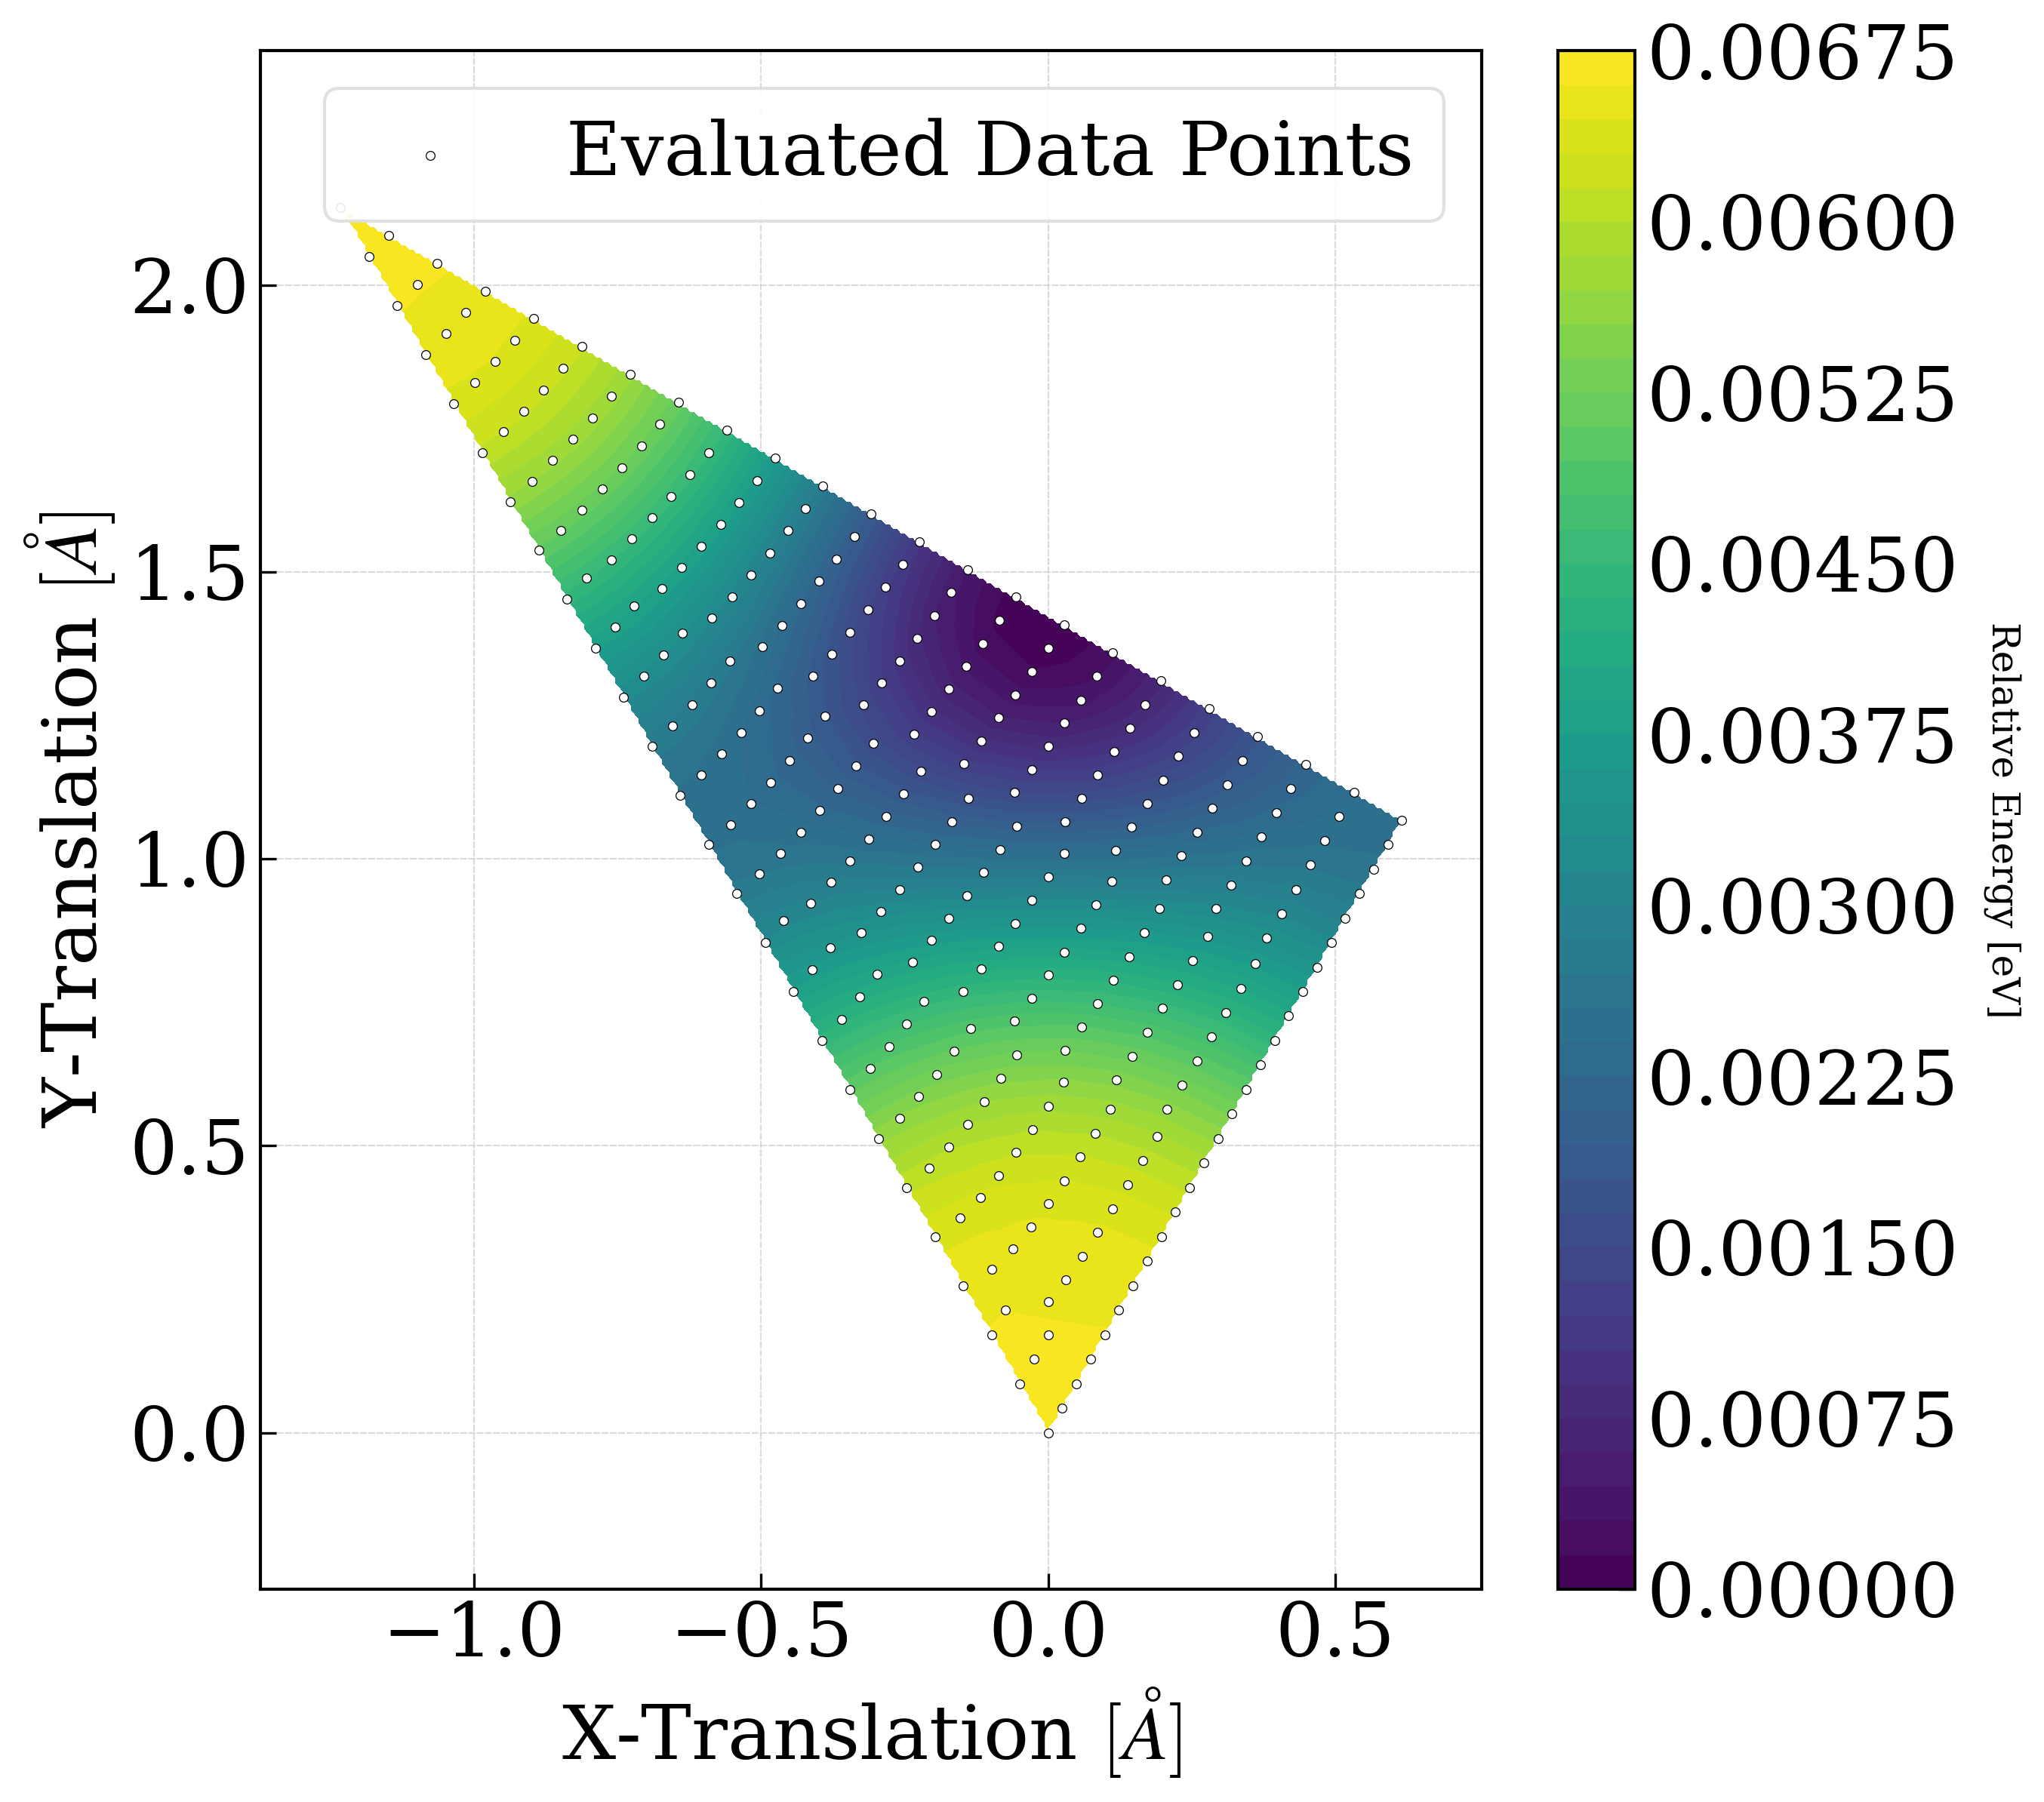

In [3]:
# ==============================================================================
# 5. MATPLOTLIB PLOTTING (ACTUAL COMPUTED POINTS ONLY)
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.interpolate import griddata
import numpy as np

OUTDIR = "v1newsplit"
PLOT_FILE = OUTDIR + "graphene_potential_map.pdf"

print("\n--- Generating PES Map for Actually Computed Points ---")
scan_positions = np.array(scan_positions)
scan_energies = np.array(scan_energies)
scan_energies -= np.min(scan_energies)  # Relative energy shift (min to 0)

# Set dynamic boundaries tightly matching only the parsed region limits
x_min, x_max = np.min(scan_positions[:, 0]), np.max(scan_positions[:, 0])
y_min, y_max = np.min(scan_positions[:, 1]), np.max(scan_positions[:, 1])

# Pad boundary view slightly so points on the edge are fully visible
pad_x = (x_max - x_min) * 0.05 if x_max > x_min else 0.5
pad_y = (y_max - y_min) * 0.05 if y_max > y_min else 0.5

grid_x, grid_y = np.mgrid[(x_min - pad_x):(x_max + pad_x):300j, 
                          (y_min - pad_y):(y_max + pad_y):300j]

# Interpolate directly using only raw scanned coordinates
grid_z = griddata(scan_positions, scan_energies, (grid_x, grid_y), method='linear')

# Plot setup
plt.figure(figsize=(9, 8))

# Draw the contour map where valid interpolated data exists
contour = plt.contourf(grid_x, grid_y, grid_z, levels=60, cmap='viridis')
cbar = plt.colorbar(contour)
cbar.set_label('Relative Energy [eV]', rotation=270, labelpad=20, fontsize=12)

# Scatter all parsed coordinates
plt.scatter(scan_positions[:, 0], scan_positions[:, 1], 
            color='white', s=8, edgecolor='black', linewidths=0.3, label='Evaluated Data Points')

# Reference cell perimeter projection line
#cell_poly = Polygon([[0,0], a1[:2], (a1+a2)[:2], a2[:2]], 
                    #closed=True, fill=False, edgecolor='red', lw=1.5, ls='--', label='Primitive Reference Cell')
#plt.gca().add_patch(cell_poly)

plt.xlabel(r'X-Translation $[\AA]$')
plt.ylabel(r'Y-Translation $[\AA]$')
#plt.title('Bernal Bilayer Graphene Potential Energy Surface (Irreducible Scan Region)', fontsize=13, pad=15)
plt.legend(loc='upper right', framealpha=0.9)
plt.axis('equal')

# Explicitly fit plot layout to scanned domain window
plt.xlim(x_min - pad_x, x_max + pad_x)
plt.ylim(y_min - pad_y, y_max + pad_y)

plt.tight_layout()
plt.savefig(PLOT_FILE)
print(f"Success! Map rendering generated and saved to '{PLOT_FILE}'")